# 4. Unsupervised Visual Anomaly Detection with a Convolutional Autoencoder
### Level: Advanced | Data: Image | Task: Unsupervised anomaly detection + localization

**Industrial context.** The hardest inspection problems have no labeled defects: the defect
catalogue is open-ended (a new failure mode can appear tomorrow) and defective samples are rare.
The industrial answer is **one-class learning**: train only on OK images, then flag anything
the model can't explain. This is the setting of the MVTec AD benchmark.

**The autoencoder idea.** Squeeze the image through a low-dimensional bottleneck and reconstruct it.
The network learns to reconstruct *normal* texture well. A defect it has never seen can't pass
through the bottleneck, so it reconstructs badly - and the **per-pixel reconstruction error is a
defect heat map**, giving localization for free.

**What you'll learn**

* Building and training a convolutional autoencoder on normal images only
* Turning reconstruction error into (a) an image-level anomaly score and (b) a pixel-level heat map
* Setting the alarm threshold from normal data (percentile method) and evaluating with ROC-AUC

**Requirements:** `numpy scipy matplotlib tensorflow scikit-learn` (CPU, ~1-2 minutes)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import tensorflow as tf
from tensorflow import keras

rng = np.random.default_rng(3)
tf.random.set_seed(3)
IMG = 64

I0000 00:00:1783549615.074584      14 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Data: normal texture + unseen defect types

Same brushed-metal texture generator as notebook 3. Crucially, the training set contains
**only normal images**. Defects (scratches, pits, cracks, and a *stain* type the pipeline has
never defined before) appear only at test time - just like production.

In [2]:
def base_texture():
    img = rng.normal(0.5, 0.12, (IMG, IMG))
    img = gaussian_filter(img, sigma=(0.5, 2.5))
    img += 0.05 * np.sin(np.linspace(0, rng.uniform(4, 9)*np.pi, IMG))[:, None]
    return img * rng.uniform(0.9, 1.1) + rng.uniform(-0.04, 0.04)

def add_defect(img, kind):
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    if kind == 'scratch':
        x0, y0 = rng.uniform(8, IMG-8, 2)
        ang, L = rng.uniform(0, np.pi), rng.uniform(25, 50)
        xs = (x0 + np.cos(ang)*np.linspace(-L/2, L/2, 200)).astype(int)
        ys = (y0 + np.sin(ang)*np.linspace(-L/2, L/2, 200)).astype(int)
        m = (xs >= 0) & (xs < IMG) & (ys >= 0) & (ys < IMG)
        img[ys[m], xs[m]] += 0.5
    elif kind == 'pit':
        for _ in range(rng.integers(2, 5)):
            cy, cx = rng.uniform(6, IMG-6, 2)
            r = rng.uniform(1.5, 3.5)
            img[(yy-cy)**2 + (xx-cx)**2 < r**2] -= 0.4
    elif kind == 'crack':
        y, x = rng.uniform(10, IMG-10, 2)
        for _ in range(60):
            y += rng.normal(0, 0.9); x += rng.normal(1.0, 0.6)
            yi, xi = int(y), int(x)
            if 0 <= yi < IMG and 0 <= xi < IMG:
                img[yi, xi] -= 0.4
    elif kind == 'stain':                      # a defect type "nobody anticipated"
        cy, cx = rng.uniform(15, IMG-15, 2)
        r = rng.uniform(6, 11)
        d2 = (yy-cy)**2 + (xx-cx)**2
        img += 0.25 * np.exp(-d2/(2*r**2)) * rng.choice([-1, 1])
    return gaussian_filter(img, 0.4)

def make(kind=None):
    img = base_texture()
    if kind:
        img = add_defect(img, kind)
    return np.clip(img, 0, 1).astype(np.float32)

# training data: NORMAL ONLY
X_train = np.stack([make() for _ in range(500)])[..., None]
# validation (normal, for threshold setting) and test (normal + all defect kinds)
X_val = np.stack([make() for _ in range(100)])[..., None]
KINDS = ['scratch', 'pit', 'crack', 'stain']
X_test = np.stack([make() for _ in range(100)] +
                  [make(k) for k in KINDS for _ in range(25)])[..., None]
y_test = np.array([0]*100 + [1]*100)          # 0 normal, 1 defective
print('train', X_train.shape, '| test', X_test.shape, '| defect rate', y_test.mean())

train (500, 64, 64, 1) | test (200, 64, 64, 1) | defect rate 0.5


## 2. The convolutional autoencoder

Encoder: 64x64 -> 8x8 feature map -> 64-d latent vector. Decoder mirrors it with transposed
convolutions. The **bottleneck size is the key knob**:

* too large -> the AE copies *everything*, including defects -> no anomaly signal
* too small -> normal texture also reconstructs badly -> noisy scores

In [3]:
LATENT = 64

def build_ae():
    enc = keras.Sequential([
        keras.layers.Input((IMG, IMG, 1)),
        keras.layers.Conv2D(16, 3, strides=2, padding='same', activation='relu'),  # 32x32
        keras.layers.Conv2D(32, 3, strides=2, padding='same', activation='relu'),  # 16x16
        keras.layers.Conv2D(64, 3, strides=2, padding='same', activation='relu'),  # 8x8
        keras.layers.Flatten(),
        keras.layers.Dense(LATENT),
    ], name='encoder')
    dec = keras.Sequential([
        keras.layers.Input((LATENT,)),
        keras.layers.Dense(8*8*64, activation='relu'),
        keras.layers.Reshape((8, 8, 64)),
        keras.layers.Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu'),  # 16x16
        keras.layers.Conv2DTranspose(16, 4, strides=2, padding='same', activation='relu'),  # 32x32
        keras.layers.Conv2DTranspose(1, 4, strides=2, padding='same', activation='sigmoid'), # 64x64
    ], name='decoder')
    inp = keras.Input((IMG, IMG, 1))
    return keras.Model(inp, dec(enc(inp)))

ae = build_ae()
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
print(f'{ae.count_params():,} parameters')

593,009 parameters


In [4]:
# note: the input is also the target - the AE learns to reproduce normal images
hist = ae.fit(X_train, X_train, epochs=12, batch_size=64, verbose=2)

Epoch 1/12


8/8 - 2s - 211ms/step - loss: 0.0037


Epoch 2/12


8/8 - 1s - 74ms/step - loss: 0.0037


Epoch 3/12


...

8/8 - 0s - 52ms/step - loss: 0.0035


Epoch 11/12


8/8 - 0s - 55ms/step - loss: 0.0035


Epoch 12/12


8/8 - 0s - 55ms/step - loss: 0.0034


## 3. From reconstruction error to anomaly scores

For each image we compute the squared-error map, smooth it (single-pixel errors are noise),
then take the **max of the smoothed map** as the image score. Max beats mean here: a small
defect barely moves the mean error over 4,096 pixels but dominates the local maximum.

In [5]:
def error_maps(model, X):
    rec = model.predict(X, verbose=0)
    err = (X[..., 0] - rec[..., 0]) ** 2
    err = np.stack([gaussian_filter(e, 2.0) for e in err])
    return rec, err

_, err_val = error_maps(ae, X_val)
rec_test, err_test = error_maps(ae, X_test)
scores_val = err_val.reshape(len(err_val), -1).max(1)
scores_test = err_test.reshape(len(err_test), -1).max(1)

# threshold: 99th percentile of NORMAL validation scores -> ~1% false-alarm rate by design
thr = np.percentile(scores_val, 99)
print(f'threshold = {thr:.5f}')

threshold = 0.02836


image-level ROC-AUC: 0.999
[[98  2]
 [ 1 99]]
              precision    recall  f1-score   support

      normal       0.99      0.98      0.98       100
      defect       0.98      0.99      0.99       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



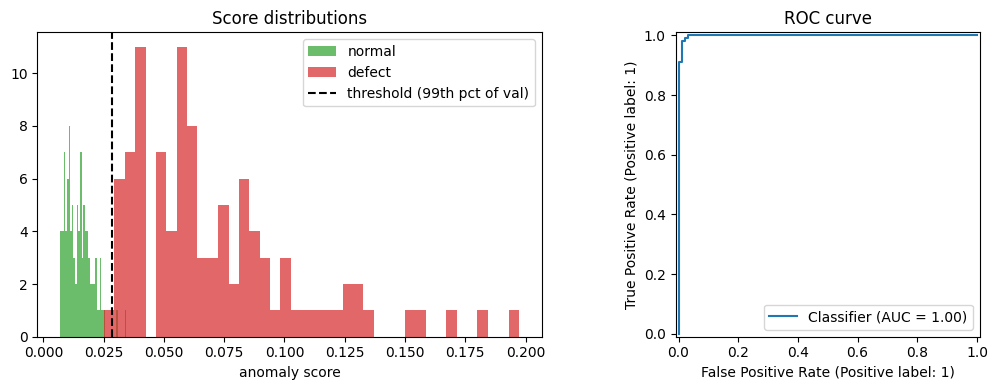

In [6]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, confusion_matrix, classification_report

pred = (scores_test > thr).astype(int)
print(f'image-level ROC-AUC: {roc_auc_score(y_test, scores_test):.3f}')
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=['normal', 'defect']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(scores_test[y_test == 0], bins=40, alpha=0.7, label='normal', color='tab:green')
axes[0].hist(scores_test[y_test == 1], bins=40, alpha=0.7, label='defect', color='tab:red')
axes[0].axvline(thr, color='k', ls='--', label='threshold (99th pct of val)')
axes[0].set_xlabel('anomaly score'); axes[0].legend(); axes[0].set_title('Score distributions')
RocCurveDisplay.from_predictions(y_test, scores_test, ax=axes[1])
axes[1].set_title('ROC curve')
plt.tight_layout(); plt.show()

## 4. Localization: defect heat maps for free

This is the part production engineers love - the model doesn't just say "bad", it shows *where*.
Note the **stain** column: the autoencoder flags a defect type that was never defined anywhere
in the training pipeline. That's the whole point of the one-class approach.

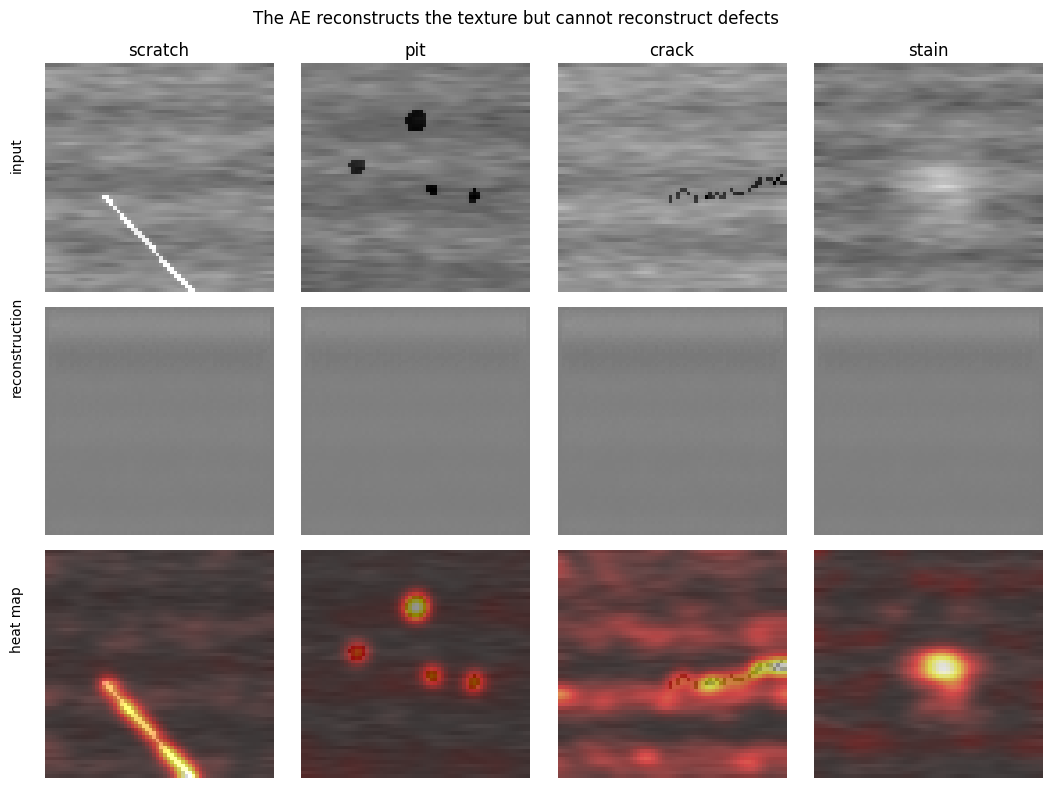

In [7]:
examples = [100, 125, 150, 175]   # first index of each defect kind in X_test
fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for j, (idx, kind) in enumerate(zip(examples, KINDS)):
    axes[0, j].imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(kind)
    axes[1, j].imshow(rec_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[2, j].imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[2, j].imshow(err_test[idx], cmap='hot', alpha=0.55)
    for i in range(3):
        axes[i, j].set_axis_off()
fig.text(0.04, 0.78, 'input', rotation=90)
fig.text(0.04, 0.5, 'reconstruction', rotation=90)
fig.text(0.04, 0.18, 'heat map', rotation=90)
plt.suptitle('The AE reconstructs the texture but cannot reconstruct defects')
plt.tight_layout(rect=(0.05, 0, 1, 1)); plt.show()

## 5. Takeaways and next steps

* One-class training matches industrial reality: abundant OK images, scarce/unknown defects.
* The threshold is a *business decision* dressed as a percentile: 99th pct of normal scores = ~1% false-alarm budget.
* Autoencoders are the teaching example; state-of-the-art industrial methods replace pixel
  reconstruction with **pretrained-feature matching**: PaDiM, PatchCore, and normalizing-flow
  methods (FastFlow) top the MVTec AD leaderboard and are available in Intel's open-source
  **anomalib** library - the fastest route to production.
* **Try it yourself:** shrink `LATENT` to 8 and grow it to 512; watch the score histograms merge or separate.
* **Real data:** MVTec AD (15 object/texture categories with pixel-level ground truth) is the standard benchmark.

---
*This completes the 4-notebook series: sensor anomaly detection -> predictive maintenance -> supervised vision -> unsupervised vision.*